# **Model Ranking and Select the Best Model**

This notebook performs a comprehensive comparison and selection of the best forecasting model for **Gold Price Forecasting**.

## Model Families

| # | Model Family | Variant Types |
|---|---|---|
| 1 | **CatBoost** | Baseline, Optuna, RandomizedSearchCV |
| 2 | **LightGBM** | Baseline, Optuna, RandomizedSearchCV |
| 3 | **XGBoost** | Baseline, Optuna, RandomizedSearchCV |
| 4 | **LSTM** | Baseline, Manual Tuning (Custom Objective), Manual Random Search |
| 5 | **Prophet** | Baseline, ChangePoint Prior Scale, Manual GridSearch |

Each model family has been individually trained, evaluated, and its performance metrics saved. This notebook aggregates all results, computes a **composite score** incorporating both standard regression metrics and domain-specific financial/directional metrics, and identifies the overall best model.

# **Import Libraries and Root Configuration**

In [1]:
""" Configure the utilities module path for imports """
import sys
import os
from pathlib import Path

# get project root as parent of current working directory
PROJECT_ROOT = Path(os.getcwd()).parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
# artifacts root
DATA_ROOT = PROJECT_ROOT / "data"
FEATURE_ROOT = PROJECT_ROOT / "artifacts" / "FeatureSelection"
FIGURE_ROOT = PROJECT_ROOT / "visualizations" / "ModelComparison"
MODEL_ROOT = PROJECT_ROOT / "artifacts" / "Models"
PERFORMANCE_ROOT = PROJECT_ROOT / "artifacts" / "ModelPerformance"

In [ ]:
# import libraries and modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import shap
import warnings
import joblib
import pickle
import json

warnings.filterwarnings("ignore")

from src.utilities import DataHandler

# **Load Artifacts and Model Performance**

In [4]:
# load train-test data
x_train = joblib.load(FEATURE_ROOT / "x_train.pkl")
x_test  = joblib.load(FEATURE_ROOT / "x_test.pkl")
y_train = joblib.load(FEATURE_ROOT / "y_train.pkl")
y_test  = joblib.load(FEATURE_ROOT / "y_test.pkl")

In [5]:
# convert to numpy arrays if they are pandas objects
if hasattr(y_train, "values"):
    y_train = y_train.values.ravel()

if hasattr(y_test, "values"):
    y_test = y_test.values.ravel()

In [6]:
# all model performance
all_perf = pd.read_csv(PERFORMANCE_ROOT / "AllModel_OverallPerformance.csv")

# all model overfitting analysis
all_overfit = pd.read_csv(PERFORMANCE_ROOT / "AllModel_OverfittingAnalysis.csv")

# all model financial metrics
all_financial = pd.read_csv(PERFORMANCE_ROOT / "AllModel_FinancialMetrics.csv")

# best variant of all models
best_variants = pd.read_csv(PERFORMANCE_ROOT / "AllModel_BestVariant.csv")

# **Model Comparison**

## Metrics Overview

In [7]:
# Table 1: Overall performance of all models
print("=== TABLE 1: Model Performance (All Models) ===".center(140))
display(all_perf)

                                              === TABLE 1: Model Performance (All Models) ===                                               


,Model,CV MSE,CV MAE,CV RMSE,CV R2,CV MAPE,CV Directional Accuracy (%),Test MSE,Test MAE,Test RMSE,Test R2,Test MAPE,Test Directional Accuracy (%),R2 Gap,RMSE Ratio,Dir Acc Gap (%),Overfitting Status,Model Status (Generalization)
0,XGBoost (RandomSearchCV),0.0001,0.0083,0.0118,-0.0040,14139.5961,52.3684,0.0001,0.0060,0.0081,-0.0001,8508.8884,51.2035,-0.0039,0.6864,-1.1649,Mild,Poor
1,XGBoost (Optuna),0.0001,0.0083,0.0118,-0.0052,11982.1378,52.3684,0.0001,0.0060,0.0081,-0.0003,11782.8189,51.2035,-0.0049,0.6864,-1.1649,Mild,Poor
2,XGBoost (Baseline),0.0002,0.0093,0.0129,-0.2029,94406.9170,51.8421,0.0001,0.0066,0.0088,-0.1872,137432.2093,47.9212,-0.0157,0.6822,-3.9209,Mild,Poor
3,LightGBM (Optuna),0.0002,0.0093,0.0129,-0.1934,111962.4241,53.4211,0.0001,0.0060,0.0081,0.0016,16306.2398,51.6411,-0.1950,0.6279,-1.7800,Mild,Poor
4,LightGBM (RandomSearchCV),0.0001,0.0083,0.0118,-0.0051,12742.0942,52.3026,0.0001,0.0060,0.0081,-0.0015,5051.7624,50.9847,-0.0036,0.6864,-1.3179,Mild,Poor
5,LightGBM (Baseline),0.0002,0.0094,0.0131,-0.2337,114227.7872,51.3816,0.0001,0.0065,0.0087,-0.1591,86473.8192,48.5777,-0.0746,0.6641,-2.8039,Mild,Poor
6,CatBoost (Optuna),0.0002,0.0088,0.0123,-0.0958,84317.3790,51.3158,0.0001,0.0060,0.0081,0.0115,11508.0825,52.2976,-0.1073,0.6585,0.9818,Mild,Poor
7,CatBoost (Baseline),0.0002,0.0091,0.0127,-0.1679,63035.5723,50.5263,0.0001,0.0060,0.0081,0.0024,8865.7085,49.6718,-0.1703,0.6378,-0.8545,Mild,Poor
8,CatBoost (RandomSearchCV),0.0001,0.0087,0.0122,-0.0686,51041.2248,51.9079,0.0001,0.0060,0.0081,0.0014,9643.8462,49.4530,-0.0700,0.6639,-2.4549,Mild,Poor
9,LSTM (Manual Tuning),0.0001,0.0083,0.0118,-0.0175,53213.3991,52.9197,0.3287,0.4239,0.5733,-0.0003,100.1285,49.6756,-0.0172,48.5847,-3.2441,High,Poor


In [8]:
# Table 2: Overfitting Analysis
print("=== TABLE 2: OVERFITTING ANALYSIS ===".center(140))
display(all_overfit)

                                                   === TABLE 2: OVERFITTING ANALYSIS ===                                                    


,Model,CV RMSE,CV R2,CV Dir Acc (%),Test RMSE,Test R2,Test Dir Acc (%),R2 Gap,RMSE Ratio,Dir Acc Gap (%),Overfitting Status,Model Status (Generalization)
0,XGBoost (Baseline),0.0129,-0.2029,51.8421,0.0088,-0.1872,47.9212,-0.0157,0.6822,-3.9209,Mild,Poor
1,XGBoost (Optuna),0.0118,-0.0052,52.3684,0.0081,-0.0003,51.2035,-0.0049,0.6864,-1.1649,Mild,Poor
2,XGBoost (RandomSearchCV),0.0118,-0.0040,52.3684,0.0081,-0.0001,51.2035,-0.0039,0.6864,-1.1649,Mild,Poor
3,LightGBM (Baseline),0.0131,-0.2337,51.3816,0.0087,-0.1591,48.5777,-0.0746,0.6641,-2.8039,Mild,Poor
4,LightGBM (Optuna),0.0129,-0.1934,53.4211,0.0081,0.0016,51.6411,-0.1950,0.6279,-1.7800,Mild,Poor
5,LightGBM (RandomSearchCV),0.0118,-0.0051,52.3026,0.0081,-0.0015,50.9847,-0.0036,0.6864,-1.3179,Mild,Poor
6,CatBoost (Baseline),0.0127,-0.1679,50.5263,0.0081,0.0024,49.6718,-0.1703,0.6378,-0.8545,Mild,Poor
7,CatBoost (Optuna),0.0123,-0.0958,51.3158,0.0081,0.0115,52.2976,-0.1073,0.6585,0.9818,Mild,Poor
8,CatBoost (RandomSearchCV),0.0122,-0.0686,51.9079,0.0081,0.0014,49.4530,-0.0700,0.6639,-2.4549,Mild,Poor
9,LSTM (Baseline),0.0118,-0.0067,52.3944,0.5811,-0.0008,49.9170,-0.0059,49.2458,-2.4774,High,Poor


In [9]:
# Table 3: Financial Metrics
print("=== TABLE 3: Financial Metrics (All Models) ===".center(140))
display(all_financial)

                                              === TABLE 3: Financial Metrics (All Models) ===                                               


,Model,Sharpe Ratio,Sortino Ratio,Max Drawdown,Total Return (%)
0,XGBoost (Baseline),-1.8415,-2.6413,-3.776700e+01,-33.6179
1,XGBoost (Optuna),0.1010,0.1642,-1.760190e+01,4.5879
2,XGBoost (RandomSearchCV),0.1010,0.1642,-1.760190e+01,4.5879
3,LightGBM (Baseline),-1.4080,-2.0366,-3.294340e+01,-26.6162
4,LightGBM (Optuna),-0.3052,-0.4686,-2.522130e+01,-4.8745
5,LightGBM (RandomSearchCV),0.0100,0.0162,-1.277170e+01,2.3954
6,CatBoost (Baseline),0.0187,0.0347,-1.419840e+01,2.6074
7,CatBoost (Optuna),0.3632,0.6086,-1.097390e+01,11.1651
8,CatBoost (RandomSearchCV),-0.8286,-1.3101,-2.082840e+01,-15.9136
9,LSTM (Baseline),0.2371,0.3323,-1.469990e+13,-100.0000


In [10]:
# Table 4: best variation from eeach model family
print("=== TABLE 4: BEST VARIANTS OF ALL MODELS ===".center(140))
display(best_variants)

                                                === TABLE 4: BEST VARIANTS OF ALL MODELS ===                                                


,Model,CV MSE,CV MAE,CV RMSE,CV R2,CV MAPE,CV Directional Accuracy (%),Test MSE,Test MAE,Test RMSE,Test R2,Test MAPE,Test Directional Accuracy (%),R2 Gap,RMSE Ratio,Dir Acc Gap (%),Overfitting Status,Model Status (Generalization)
0,XGBoost (RandomSearchCV),0.0001,0.0083,0.0118,-0.0040,14139.5961,52.3684,0.0001,0.0060,0.0081,-0.0001,8508.8884,51.2035,-0.0039,0.6864,-1.1649,Mild,Poor
1,LightGBM (Optuna),0.0002,0.0093,0.0129,-0.1934,111962.4241,53.4211,0.0001,0.0060,0.0081,0.0016,16306.2398,51.6411,-0.1950,0.6279,-1.7800,Mild,Poor
2,CatBoost (Optuna),0.0002,0.0088,0.0123,-0.0958,84317.3790,51.3158,0.0001,0.0060,0.0081,0.0115,11508.0825,52.2976,-0.1073,0.6585,0.9818,Mild,Poor
3,LSTM (Manual Tuning),0.0001,0.0083,0.0118,-0.0175,53213.3991,52.9197,0.3287,0.4239,0.5733,-0.0003,100.1285,49.6756,-0.0172,48.5847,-3.2441,High,Poor
4,Prophet (ChangePoint),0.0001,0.0080,0.0112,-0.0572,24627.6569,50.6316,0.0001,0.0060,0.0081,0.0043,11852.9633,51.2035,-0.0615,0.7232,0.5719,Mild,Poor


In [11]:
# create a temporary column for the absolute Dir Acc Gap 
best_variants['_abs_dir_gap'] = best_variants['Dir Acc Gap (%)'].abs()

# rank the variants
best_variants = best_variants.sort_values(
    by=["Test RMSE", "Test Directional Accuracy (%)", "RMSE Ratio", "_abs_dir_gap"],
    ascending=[True, False, True, True]).reset_index(drop=True)

# drop the temporary column to maintain original structure
best_variants = best_variants.drop(columns=['_abs_dir_gap'])

In [12]:
# Table 5: Model Ranking (Based on Test RMSE, Test directional Accuracy (%), RMSE Ratio)
print("=== TABLE 5: MODEL RANKING (Based on Test RMSE, Test directional Accuracy (%), RMSE Ratio) ===".center(140))
display(best_variants)

                       === TABLE 5: MODEL RANKING (Based on Test RMSE, Test directional Accuracy (%), RMSE Ratio) ===                       


,Model,CV MSE,CV MAE,CV RMSE,CV R2,CV MAPE,CV Directional Accuracy (%),Test MSE,Test MAE,Test RMSE,Test R2,Test MAPE,Test Directional Accuracy (%),R2 Gap,RMSE Ratio,Dir Acc Gap (%),Overfitting Status,Model Status (Generalization)
0,CatBoost (Optuna),0.0002,0.0088,0.0123,-0.0958,84317.3790,51.3158,0.0001,0.0060,0.0081,0.0115,11508.0825,52.2976,-0.1073,0.6585,0.9818,Mild,Poor
1,LightGBM (Optuna),0.0002,0.0093,0.0129,-0.1934,111962.4241,53.4211,0.0001,0.0060,0.0081,0.0016,16306.2398,51.6411,-0.1950,0.6279,-1.7800,Mild,Poor
2,XGBoost (RandomSearchCV),0.0001,0.0083,0.0118,-0.0040,14139.5961,52.3684,0.0001,0.0060,0.0081,-0.0001,8508.8884,51.2035,-0.0039,0.6864,-1.1649,Mild,Poor
3,Prophet (ChangePoint),0.0001,0.0080,0.0112,-0.0572,24627.6569,50.6316,0.0001,0.0060,0.0081,0.0043,11852.9633,51.2035,-0.0615,0.7232,0.5719,Mild,Poor
4,LSTM (Manual Tuning),0.0001,0.0083,0.0118,-0.0175,53213.3991,52.9197,0.3287,0.4239,0.5733,-0.0003,100.1285,49.6756,-0.0172,48.5847,-3.2441,High,Poor


## Visualize Model Comparisons

### MODEL LOADING DIAGNOSTICS

In [13]:
model_files = {
    "CatBoost": MODEL_ROOT / "CatBoost_model.pkl",
    "LightGBM": MODEL_ROOT / "LightGBM_model.pkl",
    "XGBoost": MODEL_ROOT / "XGBoost_model.pkl",
    "Prophet": MODEL_ROOT / "Prophet_model.json",
    "LSTM": MODEL_ROOT / "LSTM_model.keras",
}

print("=" * 57)
print("MODEL LOADING DIAGNOSTICS".center(57))
print("=" * 57)

for name, fpath in model_files.items():
    print("Model:", name)
    print(f"File exists? : {fpath.exists()}")
    print(f"Is file?     : {fpath.is_file() if fpath.exists() else 'N/A'}")
    
    if fpath.exists():
        fsize_mb = fpath.stat().st_size / (1024 * 1024)
        print(f"File size     : {fsize_mb:.1f} MB")
    else:
        print("File not found - skipping load.")
        print("=" * 57)
        continue
    
    print("=" * 57)
    
    print()

                MODEL LOADING DIAGNOSTICS                
Model: CatBoost
File exists? : True
Is file?     : True
File size     : 0.1 MB

Model: LightGBM
File exists? : True
Is file?     : True
File size     : 0.0 MB

Model: XGBoost
File exists? : True
Is file?     : True
File size     : 0.4 MB

Model: Prophet
File exists? : True
Is file?     : True
File size     : 2.5 MB

Model: LSTM
File exists? : True
Is file?     : True
File size     : 1.7 MB



### Visual 01: Performance Metrics Comparison Accross All Models
- Grouped bar chart comparing key error metrics for the best variant of each model family.

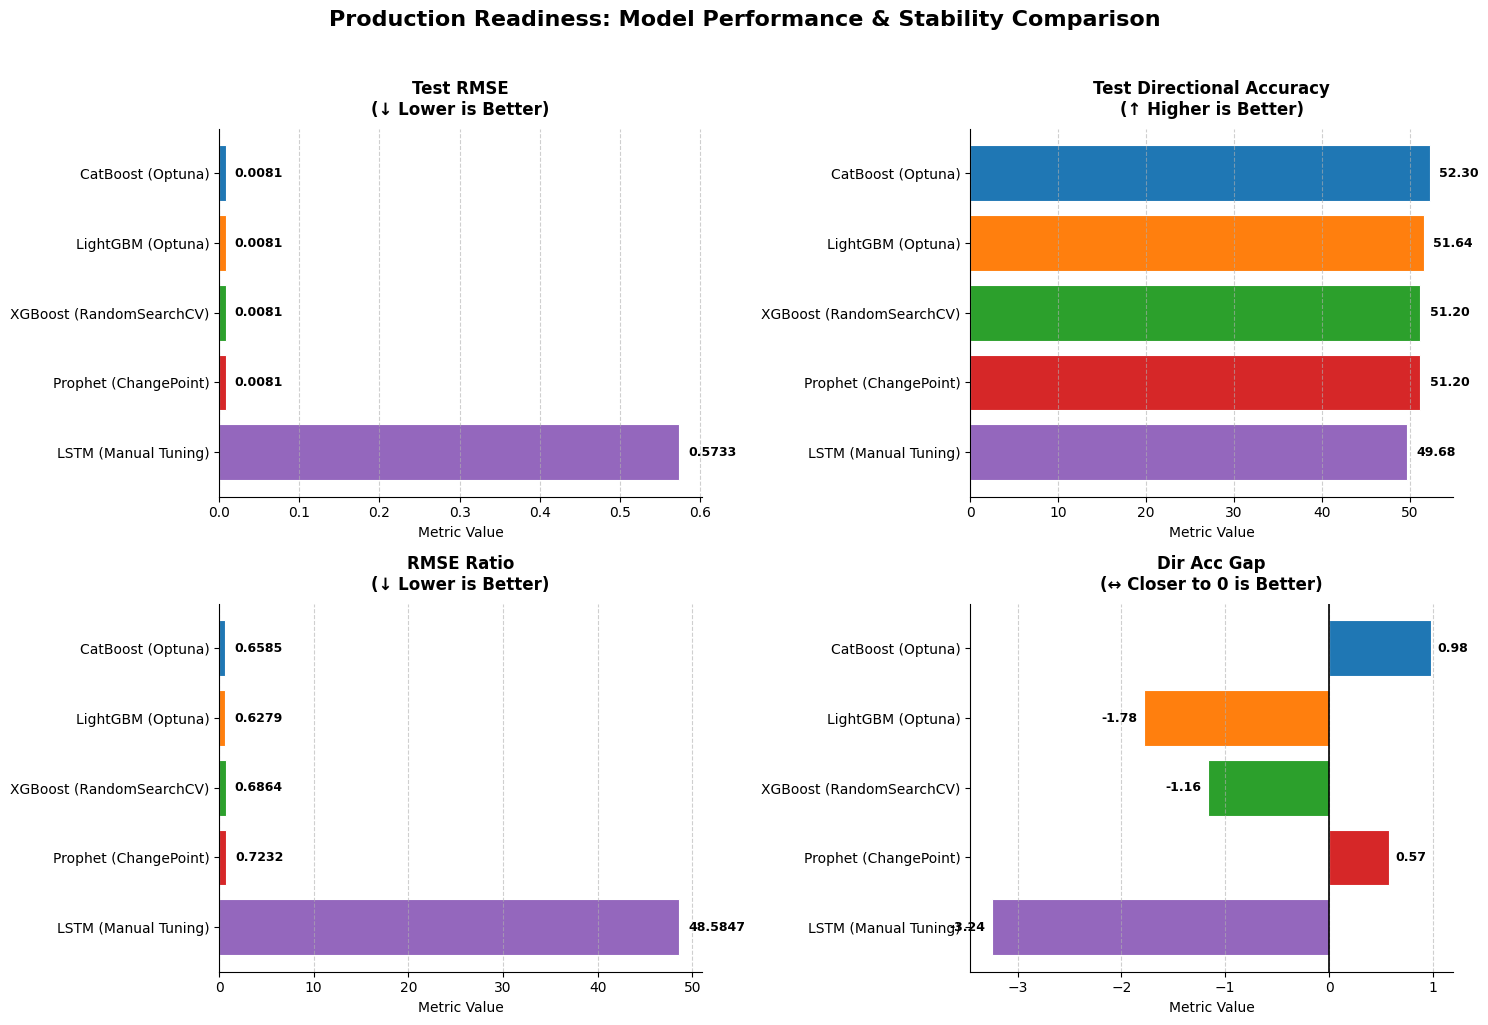

In [14]:
# metrics to display and their "better" direction
metrics_config = [
    ("Test RMSE", "Test RMSE", "↓ Lower is Better"),
    ("Test Directional Accuracy", "Test Directional Accuracy (%)", "↑ Higher is Better"),
    ("RMSE Ratio", "RMSE Ratio", "↓ Lower is Better"),
    ("Dir Acc Gap", "Dir Acc Gap (%)", "↔ Closer to 0 is Better")
]

# distinct color for each model
model_colors = [
    "#1f77b4",
    "#ff7f0e",
    "#2ca02c",
    "#d62728",
    "#9467bd"
]

# grid setup
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

# extract models
models = best_variants["Model"].tolist()
fig.subplots_adjust(left=0.25) 

# each metric in its own subplot
for ax, (title, col_name, direction) in zip(axes, metrics_config):
    values = best_variants[col_name].values.astype(float)
    
    # plot horizontal bars
    bars = ax.barh(models, values, color=model_colors, edgecolor="white", linewidth=0.8)
    
    # calculate max magnitude for dynamic text offset
    max_val = max(abs(values)) if len(values) > 0 else 1
    
    # add value annotations
    for bar, val in zip(bars, values):
        # format based on the metric
        if "RMSE" in col_name and "Ratio" not in col_name:
            text = f"{val:.4f}"
        
        elif "Ratio" in col_name:
            text = f"{val:.4f}"
        
        else:
            text = f"{val:.2f}"
            
        # handles negative values for the Gap metric perfectly
        if val >= 0:
            ax.text(val + (max_val * 0.02), bar.get_y() + bar.get_height()/2, 
                    text, va='center', ha='left', fontsize=9, fontweight='bold')
        else:
            ax.text(val - (max_val * 0.02), bar.get_y() + bar.get_height()/2, 
                    text, va='center', ha='right', fontsize=9, fontweight='bold')

    # styling
    ax.set_title(f"{title}\n({direction})", fontweight="bold", fontsize=12, pad=10)
    ax.set_xlabel("Metric Value")
    ax.grid(axis='x', linestyle='--', alpha=0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # invert Y-axis 
    ax.invert_yaxis()
    
    # special visual for the Gap metric: add a clear zero-baseline
    if "Gap" in col_name:
        ax.axvline(0, color="black", linewidth=1.2)

plt.suptitle("Production Readiness: Model Performance & Stability Comparison", 
             fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()

# Save and display
save_path = FIGURE_ROOT / "Visual01_ProductionModelComparison.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()

### Visual 02: R² Comparison (CV vs Test)
- Side-by-side bar chart comparing CV R2 and Test R2 for each best variant
- CV R² vs Test R² is the industry standard for visually demonstrating generalization

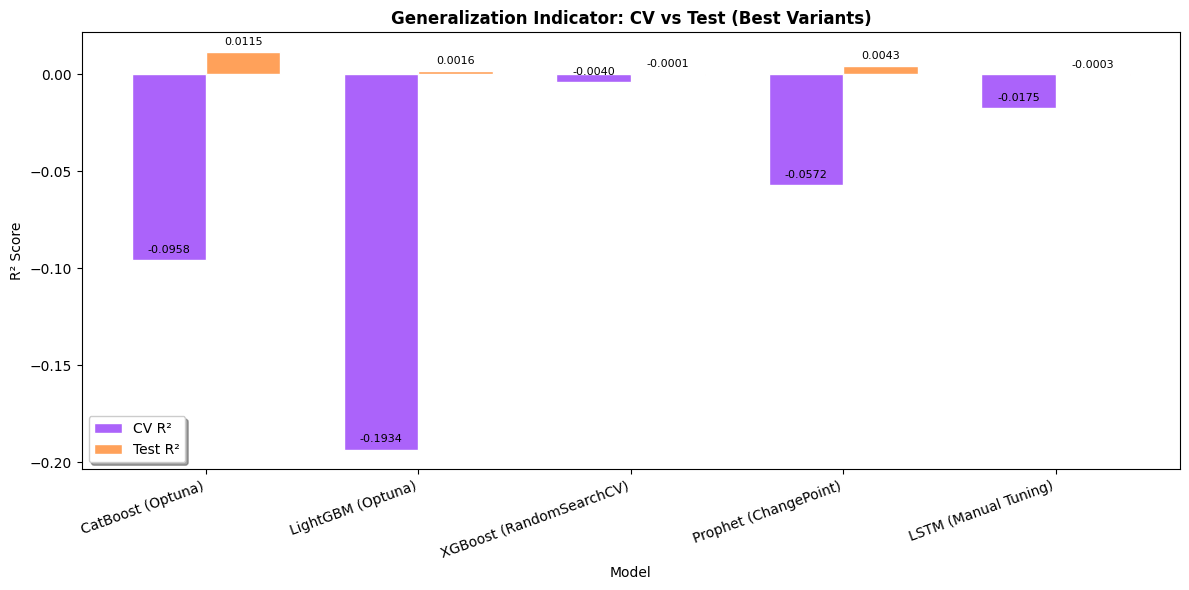

In [15]:
# extract R2 value for CV and Test
cv_vals = best_variants["CV R2"].values.astype(float)
test_vals = best_variants["Test R2"].values.astype(float)

# extract model names for the x-axis
models = best_variants["Model"].tolist()

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(models))
width = 0.35

bars1 = ax.bar(x - width/2, cv_vals,   width, label="CV R²",   color="#AB63FA", edgecolor="white")
bars2 = ax.bar(x + width/2, test_vals, width, label="Test R²", color="#FFA15A", edgecolor="white")

# annotations
for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax.annotate(f"{h:.4f}",
                xy=(bar.get_x() + bar.get_width() / 2, h),
                xytext=(0, 4), textcoords="offset points",
                ha="center", va="bottom", fontsize=8)

ax.set_xlabel("Model")
ax.set_ylabel("R² Score")
ax.set_title("Generalization Indicator: CV vs Test (Best Variants)", fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=20, ha="right")
ax.legend(frameon=True, fancybox=True, shadow=True)
plt.tight_layout()

save_path = FIGURE_ROOT / "Visual02_GeneralizationIndicator.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()

### Visual 03: Overfitting Gap Analysis
- Bar chart showing R2 Gap for each model, highlighting overfitting tendency.

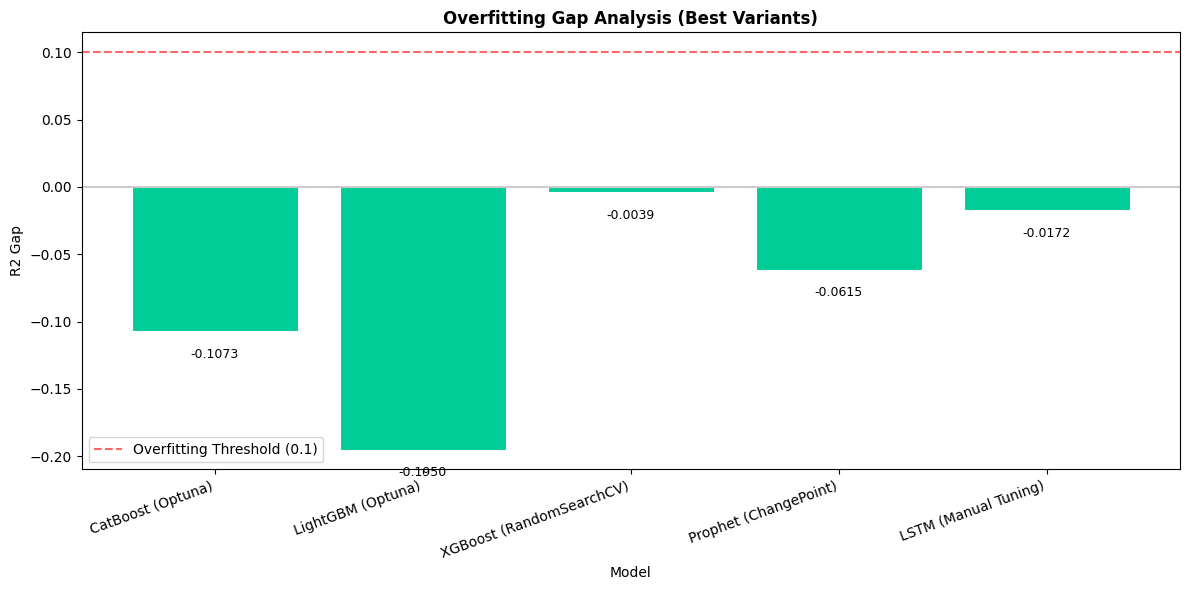

In [16]:
gap_vals = best_variants["R2 Gap"].values.astype(float)
gap_label = "R2 Gap"

# extract model names for the x-axis
models = best_variants["Model"].tolist()

fig, ax = plt.subplots(figsize=(12, 6))

# Color - Red if gap > 0.1 (severe overfitting), Green otherwise
colors_gap = ["#EF553B" if g > 0.1 else "#00CC96" for g in gap_vals]

bars = ax.bar(models, gap_vals, color=colors_gap, edgecolor="white", linewidth=0.8)

for bar, val in zip(bars, gap_vals):
    ax.annotate(f"{val:.4f}",
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 5 if val >= 0 else -12), textcoords="offset points",
                ha="center", va="bottom" if val >= 0 else "top", fontsize=9)

ax.axhline(y=0.1, color="red", linestyle="--", alpha=0.6, label="Overfitting Threshold (0.1)")
ax.axhline(y=0, color="gray", linestyle="-", alpha=0.4)
ax.set_xlabel("Model")
ax.set_ylabel(gap_label)
ax.set_title("Overfitting Gap Analysis (Best Variants)", fontweight="bold")
ax.set_xticklabels(models, rotation=20, ha="right")
ax.legend(frameon=True)
plt.tight_layout()

save_path = FIGURE_ROOT / "Visual03_OverfittingGapAnalysis.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()

### Visual 04: Key Performance Metrics Comparison
- Bar chart comparing key performance metrics from best variants.

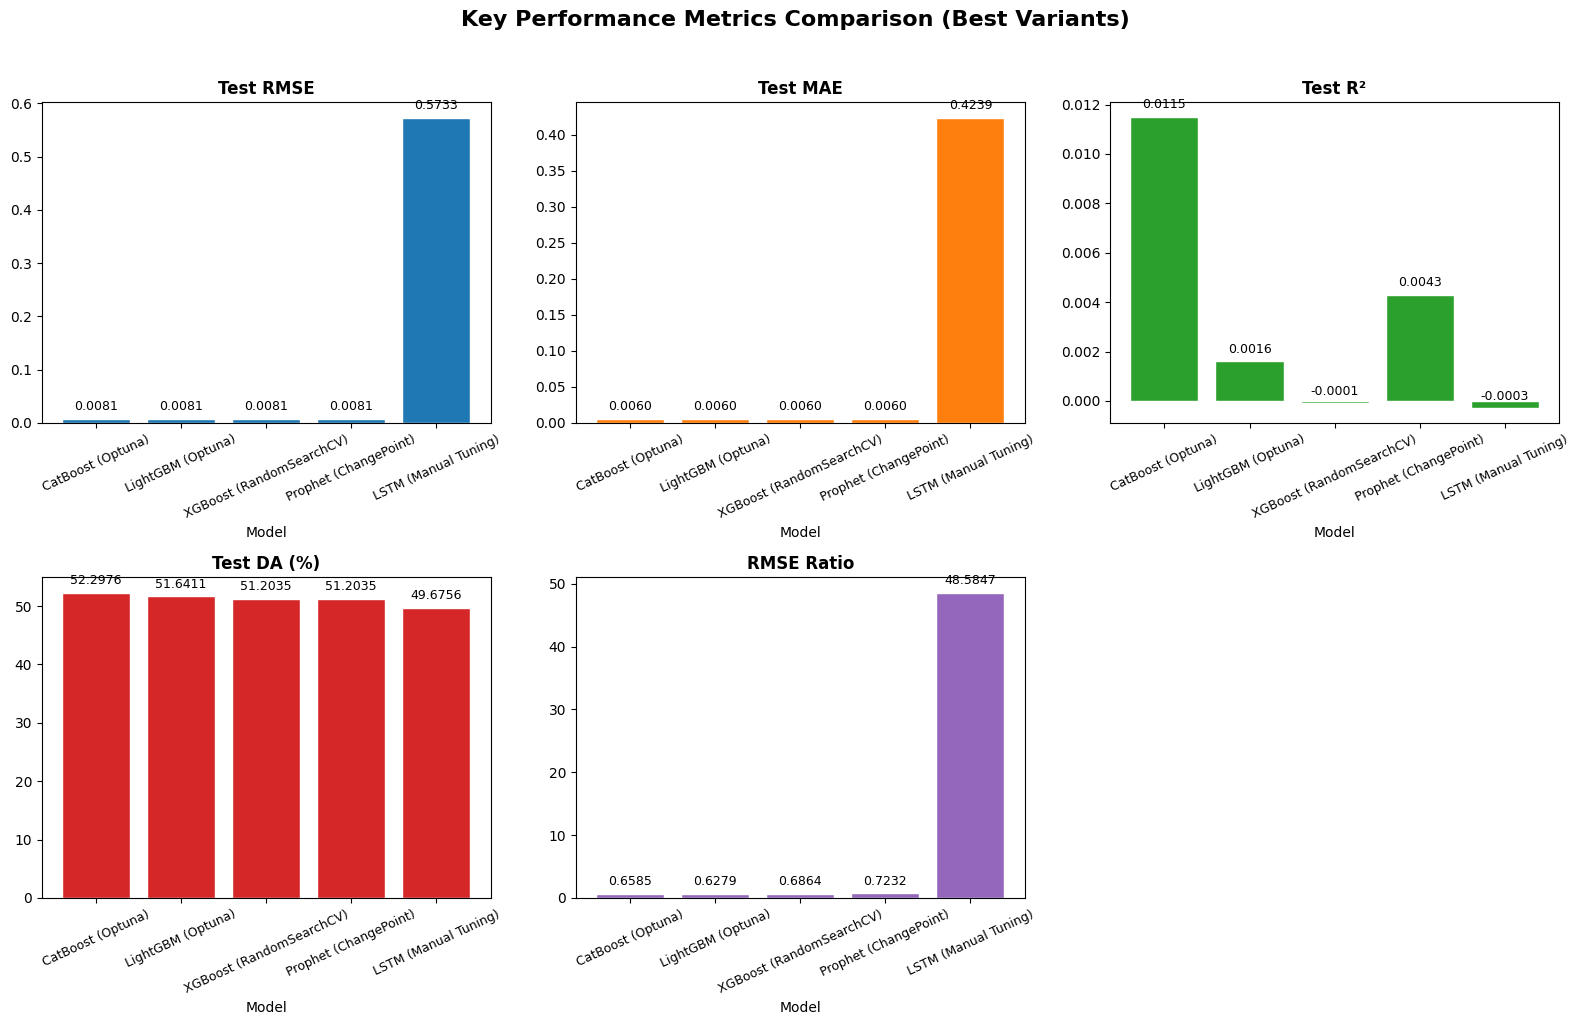

In [17]:
# extract of key metrics
metrics_to_plot = {
    "Test RMSE": "Test RMSE",
    "Test MAE": "Test MAE",
    "Test R²": "Test R2",
    "Test DA (%)": "Test Directional Accuracy (%)",
    "RMSE Ratio": "RMSE Ratio"
}

models = best_variants["Model"].tolist()

n_metrics = len(metrics_to_plot)

# create a 2x3 grid
fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharey=False)
axes = axes.flatten()

# color palette
cmap = plt.cm.tab10
bar_colors = [cmap(i) for i in range(n_metrics)]

for idx, (label, col_name) in enumerate(metrics_to_plot.items()):
    ax = axes[idx]
    vals = best_variants[col_name].values.astype(float)
    bars = ax.bar(models, vals, color=bar_colors[idx], edgecolor="white")

    # add value annotations (increased font size for better readability)
    for bar, val in zip(bars, vals):
        ax.annotate(f"{val:.4f}",
                    xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 4), textcoords="offset points",
                    ha="center", va="bottom", fontsize=9)

    ax.set_title(label, fontweight="bold", fontsize=12)
    ax.set_xlabel("Model")
    
    # adjust label size and rotation for the new layout
    ax.tick_params(axis="x", rotation=25, labelsize=9) 

# remove the empty grid
fig.delaxes(axes[5])

fig.suptitle("Key Performance Metrics Comparison (Best Variants)", fontweight="bold", fontsize=16, y=1.02)
plt.tight_layout()

save_path = FIGURE_ROOT / "Visual04_PerformanceMetricsComparison.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()

### Visual 05: Directional Accuracy Comparison
- Bar chart comparing CV and Test Directional Accuracy

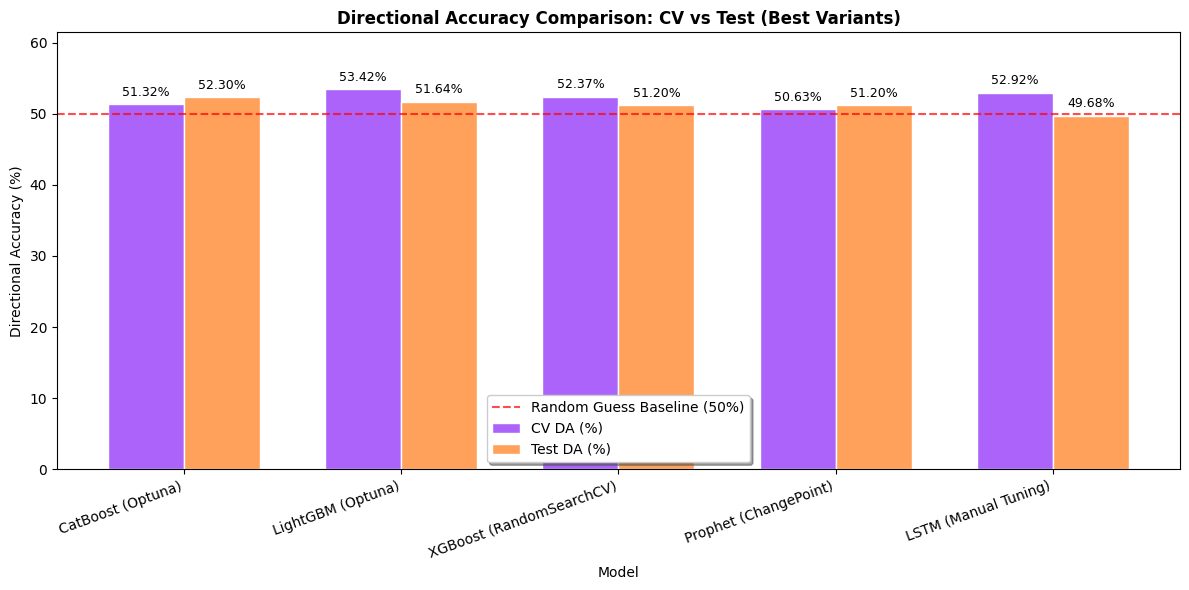

In [18]:
cv_da_vals = best_variants["CV Directional Accuracy (%)"].values.astype(float)
test_da_vals = best_variants["Test Directional Accuracy (%)"].values.astype(float)

models = best_variants["Model"].tolist()

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(models))
width = 0.35

# plot CV and Test DA side-by-side
bars1 = ax.bar(x - width/2, cv_da_vals, width, label="CV DA (%)", color="#AB63FA", edgecolor="white")
bars2 = ax.bar(x + width/2, test_da_vals, width, label="Test DA (%)", color="#FFA15A", edgecolor="white")

# annotations
for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax.annotate(f"{h:.2f}%",
                xy=(bar.get_x() + bar.get_width() / 2, h),
                xytext=(0, 4), textcoords="offset points",
                ha="center", va="bottom", fontsize=9)

# add a 50% baseline
ax.axhline(y=50, color="red", linestyle="--", alpha=0.7, label="Random Guess Baseline (50%)")

ax.set_xlabel("Model")
ax.set_ylabel("Directional Accuracy (%)")
ax.set_title("Directional Accuracy Comparison: CV vs Test (Best Variants)", fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=20, ha="right")
ax.legend(frameon=True, fancybox=True, shadow=True)

# adjust y-axis to fit the percentage values
max_val = max(max(cv_da_vals), max(test_da_vals))
ax.set_ylim(0, max_val * 1.15)

plt.tight_layout()

save_path = FIGURE_ROOT / "Visual05_DirectionalAccuracyComparison.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()

### Visual 06: Error vs. Actionability Scatter
- Scatter plot evaluating the trade-off between error magnitude (RMSE) and trading actionability (Directional Accuracy).

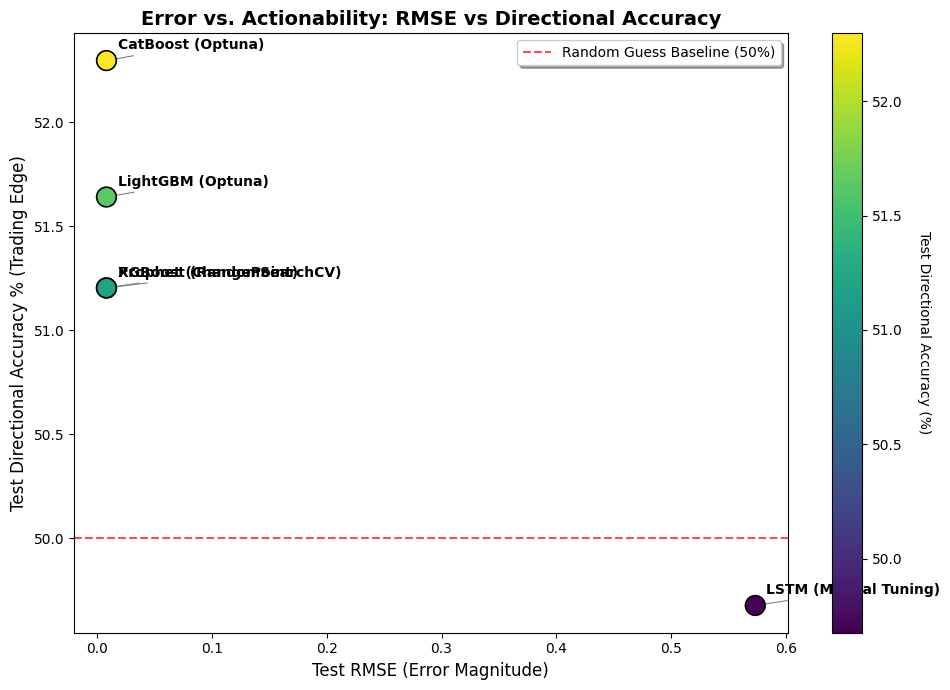

In [19]:
rmse_vals = best_variants["Test RMSE"].values.astype(float)
da_vals = best_variants["Test Directional Accuracy (%)"].values.astype(float)
models = best_variants["Model"].tolist()

fig, ax = plt.subplots(figsize=(10, 7))

# scatter plot, colored by directional Accuracy for visual impact
scatter = ax.scatter(rmse_vals, da_vals, s=200, c=da_vals, cmap="viridis",
                     edgecolors="black", linewidths=1.2, zorder=5)

# annotate each point with the model name
for i, model in enumerate(models):
    ax.annotate(model, (rmse_vals[i], da_vals[i]),
                xytext=(8, 8), textcoords="offset points",
                fontsize=10, fontweight="bold",
                arrowprops=dict(arrowstyle="->", color="gray", lw=0.8))

ax.set_xlabel("Test RMSE (Error Magnitude)", fontsize=12)
ax.set_ylabel("Test Directional Accuracy % (Trading Edge)", fontsize=12)
ax.set_title("Error vs. Actionability: RMSE vs Directional Accuracy", fontweight="bold", fontsize=14)

# add a colorbar mapped to DA
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Test Directional Accuracy (%)", rotation=270, labelpad=20)

# add a crucial financial baseline: 50% is a coin flip
ax.axhline(y=50, color="red", linestyle="--", alpha=0.7, label="Random Guess Baseline (50%)")
ax.legend(frameon=True, fancybox=True, shadow=True)

# adjust layout to ensure long model names don't get clipped
plt.subplots_adjust(right=0.85) 
plt.tight_layout()

save_path = FIGURE_ROOT / "Visual06_ErrorVsActionabilityScatter.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()

# **Final Model Ranking and Selection: Composite Score**

## Composite Score Calculation 

In [20]:
# Min-Max normalization function
def normalize_score(series, higher_is_better):
    min_val, max_val = series.min(), series.max()
    
    if max_val == min_val:
        return pd.Series([1.0] * len(series), index=series.index)
    
    if higher_is_better:
        return (series - min_val) / (max_val - min_val)
    
    else:
        return (max_val - series) / (max_val - min_val)

In [21]:
# metrics and their weights based on financial forecasting priorities
composite_metrics = {
    "Test Directional Accuracy (%)": {"weight": 0.40, "higher_is_better": True},
    "Test RMSE":                     {"weight": 0.30, "higher_is_better": False},
    "RMSE Ratio":                    {"weight": 0.15, "higher_is_better": False},
    "Abs Dir Acc Gap":               {"weight": 0.15, "higher_is_better": False}
}

# create a working copy to avoid modifying the original dataframe
final_ranking = best_variants.copy()

# recalculate absolute Dir Acc Gap
final_ranking['Abs Dir Acc Gap'] = final_ranking['Dir Acc Gap (%)'].abs()

In [22]:
# calculate normalized scores for each metric
for metric, config in composite_metrics.items():
    norm_col = f"Norm_{metric.replace(' ', '_').replace('%', '')}"
    final_ranking[norm_col] = normalize_score(final_ranking[metric], config["higher_is_better"])

In [23]:
# calculate weighted composite score
final_ranking['Composite Score'] = 0.0

for metric, config in composite_metrics.items():
    norm_col = f"Norm_{metric.replace(' ', '_').replace('%', '')}"
    final_ranking['Composite Score'] += final_ranking[norm_col] * config["weight"]

In [24]:
# sort by composite score and assign final rank
final_ranking = final_ranking.sort_values(by='Composite Score', ascending=False).reset_index(drop=True)
final_ranking.insert(0, 'Final Rank', final_ranking.index + 1)

In [25]:
# display final table
display_cols = ['Final Rank', 'Model', 'Composite Score'] + list(composite_metrics.keys())
print("=== TABLE 6: FINAL MODEL RANKING (BASED ON COMPOSITE SCORE) ===".center(120))
display(final_ranking[display_cols].round(4))

                            === TABLE 6: FINAL MODEL RANKING (BASED ON COMPOSITE SCORE) ===                             


,Final Rank,Model,Composite Score,Test Directional Accuracy (%),Test RMSE,RMSE Ratio,Abs Dir Acc Gap
0,1,CatBoost (Optuna),0.9769,52.2976,0.0081,0.6585,0.9818
1,2,Prophet (ChangePoint),0.8328,51.2035,0.0081,0.7232,0.5719
2,3,LightGBM (Optuna),0.8320,51.6411,0.0081,0.6279,1.7800
3,4,XGBoost (RandomSearchCV),0.7996,51.2035,0.0081,0.6864,1.1649
4,5,LSTM (Manual Tuning),0.0000,49.6756,0.5733,48.5847,3.2441


In [26]:
# best model and it's score
best_model = final_ranking.iloc[0]['Model']
best_model_score = final_ranking.iloc[0]['Composite Score']
print(f"OVERALL BEST MODEL: {best_model} with a Composite Score of {best_model_score:.4f}")

OVERALL BEST MODEL: CatBoost (Optuna) with a Composite Score of 0.9769


## Final Visualization

### Composite Score
- Horizontal bar chart showing the definitive ranking of all models based on their weighted composite score

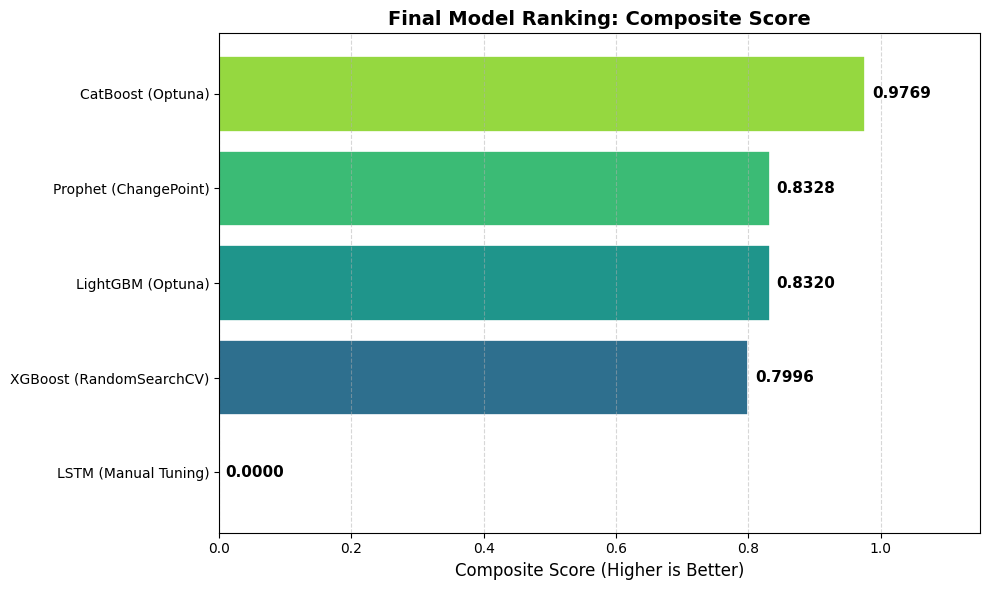

In [27]:
fig, ax = plt.subplots(figsize=(10, 6))

# sort ascending
final_ranking_sorted = final_ranking.sort_values(by='Composite Score', ascending=True)

# generate gradient of colors
cmap = plt.cm.viridis
colors_bar = [cmap(0.2 + 0.8 * i / len(final_ranking_sorted)) for i in range(len(final_ranking_sorted))]

bars = ax.barh(final_ranking_sorted['Model'], final_ranking_sorted['Composite Score'], 
               color=colors_bar, edgecolor='white', linewidth=1.2)

# add value annotations to the right of each bar
for bar, val in zip(bars, final_ranking_sorted['Composite Score']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f"{val:.4f}", 
            va='center', ha='left', fontsize=11, fontweight='bold')

ax.set_xlabel("Composite Score (Higher is Better)", fontsize=12)
ax.set_title("Final Model Ranking: Composite Score", fontweight='bold', fontsize=14)
ax.set_xlim(0, 1.15)
ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()

save_path = FIGURE_ROOT / "Visual07_FinalCompositeScore.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()

### Visual 08: Normalized Performance Profile
- Radar chart comparing the normalized performance of all 5 models

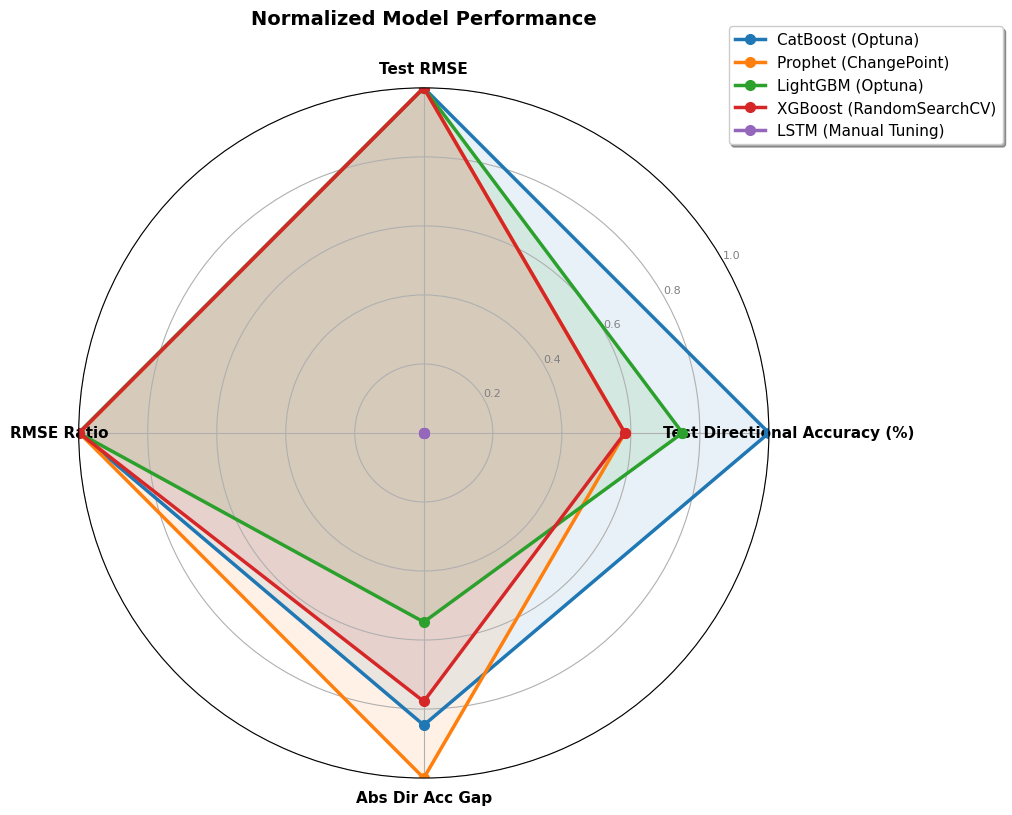

In [28]:
# extract categories and calculate angles for the radar axes
categories = list(composite_metrics.keys())

N = len(categories)

angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

# distinct colors for all models
colors_radar = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

fig, ax = plt.subplots(figsize=(10, 9), subplot_kw=dict(polar=True))

# adjust right margin
fig.subplots_adjust(right=0.75) 

# plot each model
for i, (idx, row) in enumerate(final_ranking.iterrows()):
    values = []
    
    # extract the normalized score for each metric
    for metric in categories:
        norm_col = f"Norm_{metric.replace(' ', '_').replace('%', '')}"
        values.append(row[norm_col])
    
    values += values[:1] 
    
    # plot the line and fill the area
    ax.plot(angles, values, 'o-', linewidth=2.5, label=row['Model'], 
            color=colors_radar[i], markersize=7)
    ax.fill(angles, values, alpha=0.1, color=colors_radar[i])

# format the Radar Chart
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11, fontweight='bold')
ax.set_ylim(0, 1.0)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], fontsize=8, color='grey')
ax.set_rlabel_position(30)

# place the legend outside the plot area
plt.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=11, frameon=True, shadow=True)

ax.set_title("Normalized Model Performance", size=14, fontweight='bold', y=1.08)

plt.tight_layout()

save_path = FIGURE_ROOT / "Visual08_RadarChartComparison.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()

# **Visualization of the Best Model Evaluation**

## Actual vs Predicted
- Scatter plot with perfect prediction line and regression line.

In [29]:
# get model family name and its corresponding file
best_model_family = best_model.split(" ")[0]
model_path = model_files[best_model_family]

In [30]:
# load the model object into memory based on its family
if best_model_family == "LSTM":
    import tensorflow as tf
    best_model_obj = tf.keras.models.load_model(str(model_path))

elif best_model_family == "Prophet":
    from prophet import Prophet
    best_model_obj = Prophet.load(str(model_path))

else:
    best_model_obj = joblib.load(str(model_path))

In [31]:
y_actual = y_test.copy()

# prepare the input data based on model requirements
if best_model_family == "LSTM":
    x_input = x_test.values if hasattr(x_test, "values") else x_test
    x_input = x_input.reshape(x_input.shape[0], 1, x_input.shape[1])
    y_pred = best_model_obj.predict(x_input)

elif best_model_family == "Prophet":
    # prophet expects a DataFrame with at least a 'ds' column
    x_input = DataHandler.prepare_prophet_df(DATA_ROOT / "test_df.csv")
    y_actual = x_input['y'].to_numpy(dtype=float)
    y_pred = best_model_obj.predict(x_input)['yhat'].to_numpy()

else:
    x_input = x_test 
    y_pred = best_model_obj.predict(x_input)

if hasattr(y_pred, "values"):
    y_pred = y_pred.values

y_pred = np.array(y_pred).flatten()

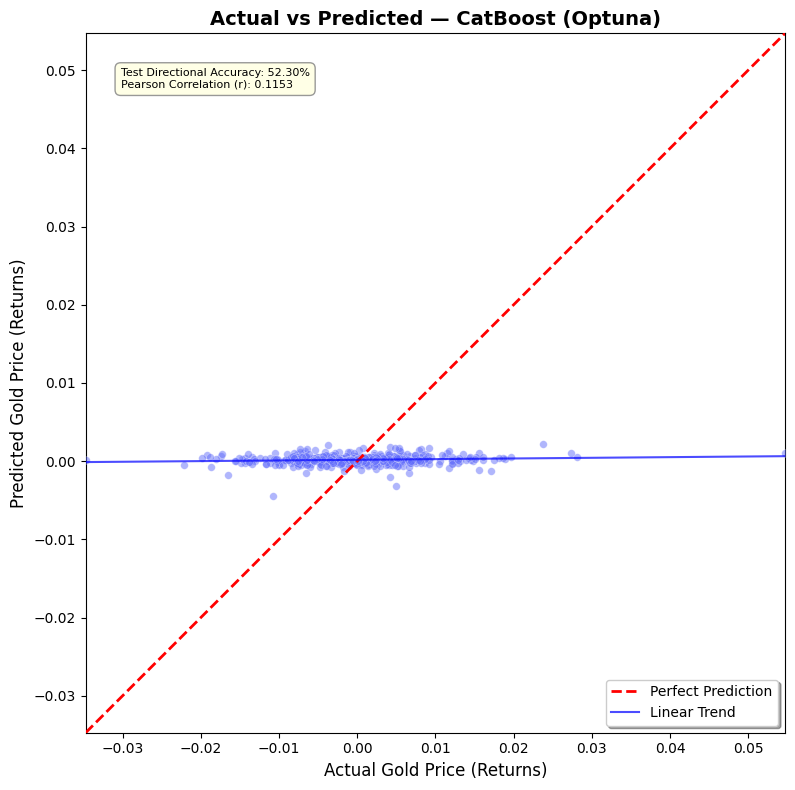

In [32]:
# ensure y_actual and y_pred are the exact same length
min_len = min(len(y_actual), len(y_pred))
y_actual = y_actual[:min_len]
y_pred = y_pred[:min_len]

# calculate residuals
residuals = y_actual - y_pred
res_std = residuals.std()

fig, ax = plt.subplots(figsize=(9, 8))

ax.scatter(y_actual, y_pred, alpha=0.5, s=30, color="#636EFA", edgecolors="white", linewidths=0.3, zorder=3)

# perfect prediction line
lims = [min(y_actual.min(), y_pred.min()), max(y_actual.max(), y_pred.max())]
ax.plot(lims, lims, "r--", linewidth=2, label="Perfect Prediction", zorder=4)

# regression line
slope, intercept, r_value, p_value, std_err = stats.linregress(y_actual, y_pred)
reg_line = slope * np.array(lims) + intercept
ax.plot(lims, reg_line, "b-", linewidth=1.5, alpha=0.7, label="Linear Trend", zorder=4)

da_score = np.mean((np.sign(y_pred) == np.sign(y_actual))) * 100
textstr = f"Test Directional Accuracy: {da_score:.2f}%\nPearson Correlation (r): {r_value:.4f}"
props = dict(boxstyle="round,pad=0.5", facecolor="lightyellow", alpha=0.8, edgecolor="gray")

ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=8,
        verticalalignment="top", horizontalalignment="left", bbox=props, zorder=5)

ax.set_xlabel("Actual Gold Price (Returns)", fontsize=12)
ax.set_ylabel("Predicted Gold Price (Returns)", fontsize=12)
ax.set_title(f"Actual vs Predicted — {best_model}", fontweight="bold", fontsize=14)
ax.legend(frameon=True, fancybox=True, shadow=True, loc="lower right")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect("equal", adjustable="box")
plt.tight_layout()

save_path = FIGURE_ROOT / "BestModel_Actual_vs_Predicted.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()

## Residuals vs Predicted
- Checks for homoscedasticity (constant variance of errors).

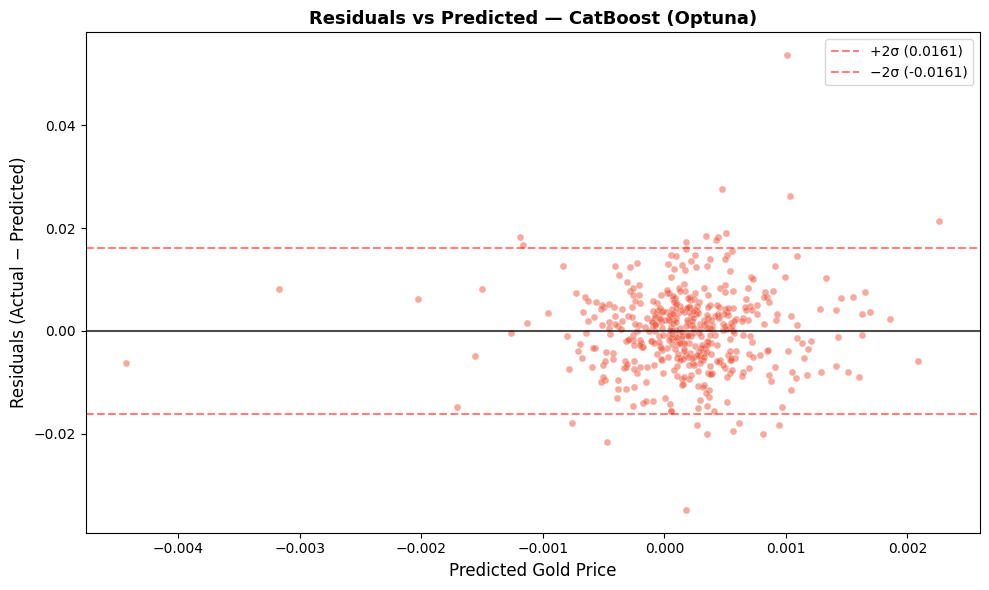

In [33]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(y_pred, residuals, alpha=0.5, s=25, color="#EF553B", edgecolors="white", linewidths=0.3)
ax.axhline(y=0, color="black", linestyle="-", linewidth=1.5, alpha=0.7)

ax.axhline(y=2*res_std,  color="red", linestyle="--", alpha=0.5, label=f"+2σ ({2*res_std:.4f})")
ax.axhline(y=-2*res_std, color="red", linestyle="--", alpha=0.5, label=f"−2σ ({-2*res_std:.4f})")

ax.set_xlabel("Predicted Gold Price", fontsize=12)
ax.set_ylabel("Residuals (Actual − Predicted)", fontsize=12)
ax.set_title(f"Residuals vs Predicted — {best_model}", fontweight="bold", fontsize=13)
ax.legend(frameon=True)
plt.tight_layout()

save_path = FIGURE_ROOT / "BestModel_Residuals_vs_Predicted.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()

## Residuals Normality Checks
- Histogram and Q-Q Plot

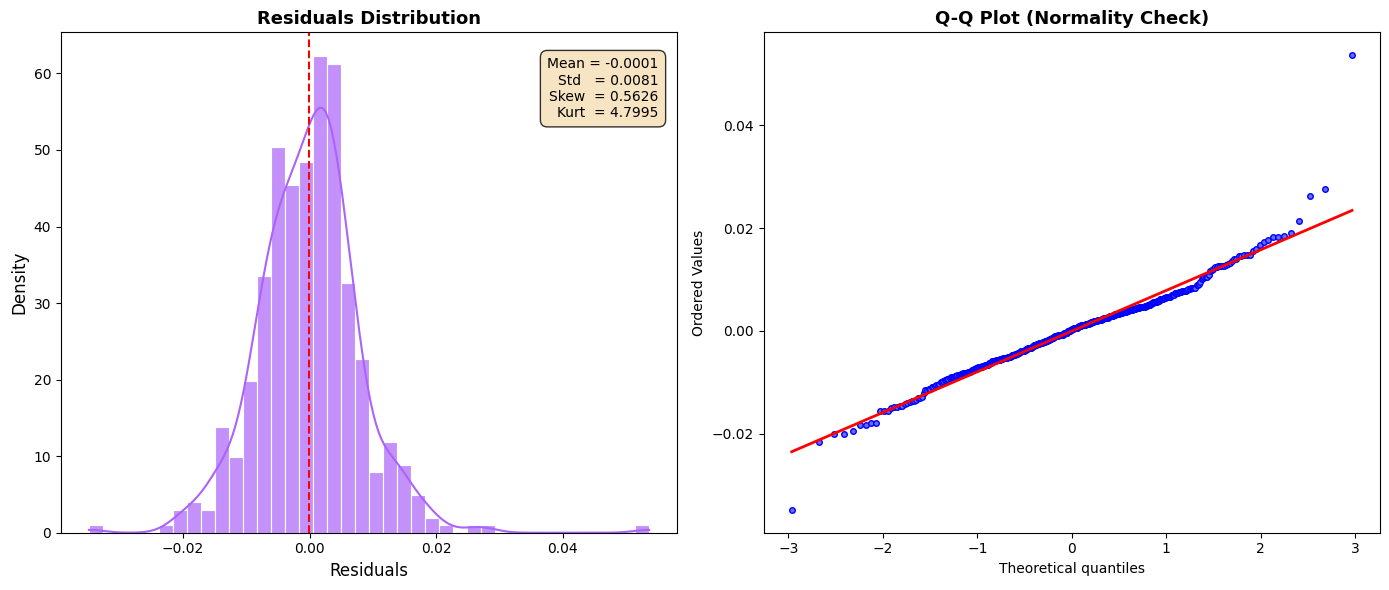

In [34]:
# residuals mean
res_mean = residuals.mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histogram with KDE
sns.histplot(residuals, kde=True, bins=40, color="#AB63FA", edgecolor="white",
             alpha=0.7, ax=axes[0], stat="density")

axes[0].axvline(res_mean, color="red", linestyle="--", linewidth=1.5)

# add statistical text box
textstr = f"Mean = {res_mean:.4f}\nStd   = {res_std:.4f}\nSkew  = {stats.skew(residuals):.4f}\nKurt  = {stats.kurtosis(residuals):.4f}"
props = dict(boxstyle="round,pad=0.5", facecolor="wheat", alpha=0.8)
axes[0].text(0.97, 0.95, textstr, transform=axes[0].transAxes, fontsize=10,
             verticalalignment="top", horizontalalignment="right", bbox=props)

axes[0].set_xlabel("Residuals", fontsize=12)
axes[0].set_ylabel("Density", fontsize=12)
axes[0].set_title("Residuals Distribution", fontweight="bold", fontsize=13)

# Q-Q Plot
stats.probplot(residuals, dist="norm", plot=axes[1])

axes[1].get_lines()[0].set_markerfacecolor("#636EFA")
axes[1].get_lines()[0].set_markersize(4)
axes[1].get_lines()[1].set_color("red")
axes[1].get_lines()[1].set_linewidth(2)
axes[1].set_title("Q-Q Plot (Normality Check)", fontweight="bold", fontsize=13)

plt.tight_layout()

save_path = FIGURE_ROOT / "BestModel_Residuals_Normality.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()

## Residuals Over Time & Autocorrelation (ACF)
- Crucial for Time Series: Checks if residuals are "white noise"

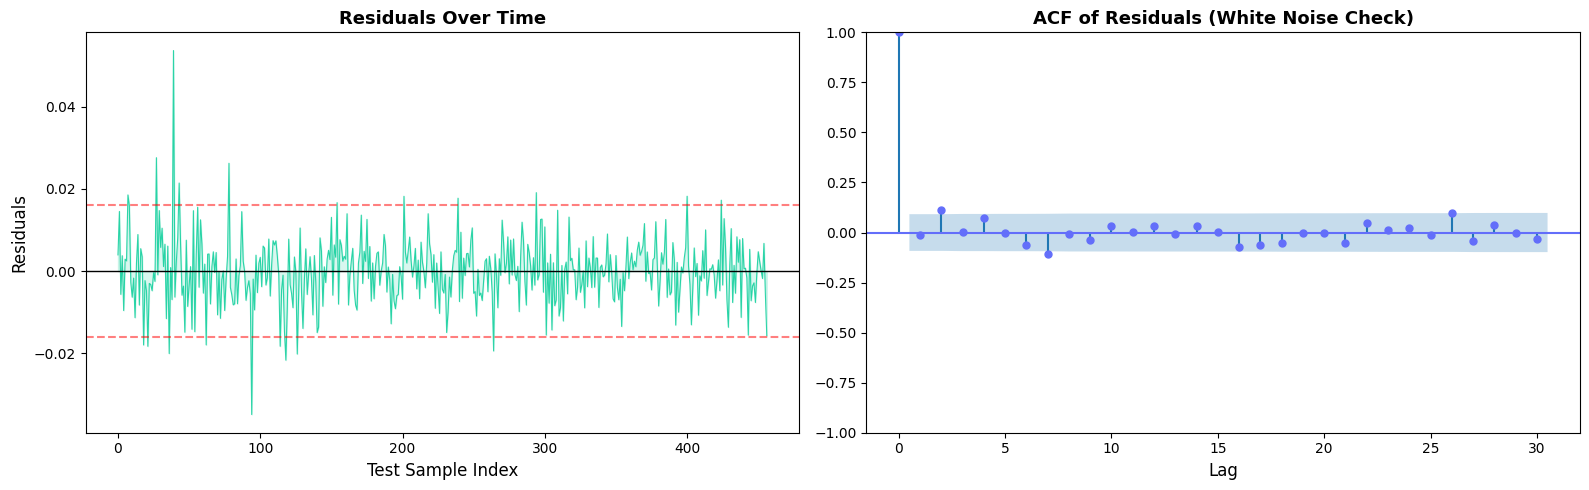

In [35]:
from statsmodels.graphics.tsaplots import plot_acf

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# residuals over time
axes[0].plot(range(len(residuals)), residuals, color="#00CC96", linewidth=0.8, alpha=0.8)
axes[0].fill_between(range(len(residuals)), residuals, 0, alpha=0.15, color="#00CC96")
axes[0].axhline(y=0, color="black", linestyle="-", linewidth=1)
axes[0].axhline(y=2*res_std,  color="red", linestyle="--", alpha=0.5)
axes[0].axhline(y=-2*res_std, color="red", linestyle="--", alpha=0.5)

axes[0].set_xlabel("Test Sample Index", fontsize=12)
axes[0].set_ylabel("Residuals", fontsize=12)
axes[0].set_title("Residuals Over Time", fontweight="bold", fontsize=13)

# ACF plot (Autocorrelation Function)
# If the blue bars stay within the shaded confidence interval, the residuals are white noise
plot_acf(residuals, ax=axes[1], lags=30, alpha=0.05, color="#636EFA")
axes[1].set_title("ACF of Residuals (White Noise Check)", fontweight="bold", fontsize=13)
axes[1].set_xlabel("Lag", fontsize=12)

plt.tight_layout()

save_path = FIGURE_ROOT / "BestModel_Residuals_Time_and_ACF.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()

## SHAP Summary Feature Importance
- Generate SHAP beeswarm plot for the best tree-based model

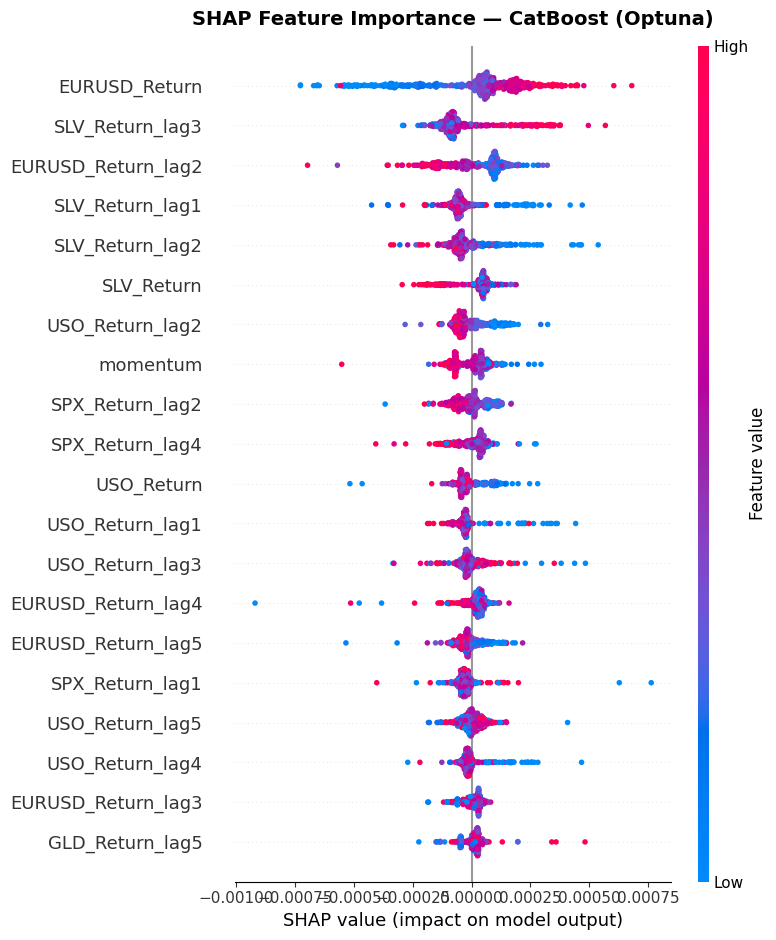

In [36]:
x_input = x_test.values if hasattr(x_test, "values") else x_test
feature_names = x_test.columns.tolist() if hasattr(x_test, "columns") else [f"f{i}" for i in range(x_input.shape[1])]

try:
    if best_model_family in ["CatBoost", "LightGBM", "XGBoost"]:
        
        # TreeExplainer for Tree-based model
        explainer = shap.TreeExplainer(best_model_obj)
        shap_values = explainer.shap_values(x_input)
        
        fig, ax = plt.subplots(figsize=(12, 8))
        shap.summary_plot(shap_values, x_input, feature_names=feature_names, show=False)
        plt.title(f"SHAP Feature Importance — {best_model}", fontweight="bold", fontsize=14, pad=15)
        plt.tight_layout()
        
        save_path = FIGURE_ROOT / "BestModel_SHAP_Summary.png"
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        plt.show()
    
    
    # KernelExplainer with a background sample
    elif best_model_family == "LSTM":
        """
            SHAP does not directly support LSTM models.
            Using KernelExplainer may be slow or skipping.
        """
        
        background = shap.sample(x_input, 50)
        
        def model_predict(x):
            x_3d = x.reshape(x.shape[0], 1, x.shape[1])
            
            return best_model_obj.predict(x_3d).flatten()
        
        explainer = shap.KernelExplainer(model_predict, background)
        shap_values = explainer.shap_values(shap.sample(x_input, 100))
        
        fig, ax = plt.subplots(figsize=(12, 8))
        
        shap.summary_plot(shap_values[0] if isinstance(shap_values, list) else shap_values,
                         shap.sample(x_input, 100), feature_names=feature_names, show=False)
        plt.title(f"SHAP Feature Importance — {best_model} (KernelExplainer)", fontweight="bold", fontsize=14, pad=15)
        plt.tight_layout()
        
        save_path = FIGURE_ROOT / "BestModel_SHAP_Summary.png"
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        plt.show()
    
    elif best_model_family == "Prophet":
        """
            SHAP does not support Prophet models directly as well.
            Prophet is a time series model with additive components,
            and SHAP is primarily designed for supervised learning models
        """
        print("Prophet uses additive components; consider Prophet's built-in component plots instead.")

except Exception as e:
    print(f"SHAP computation failed: {e}")